In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_classic.chains import RetrievalQA

from common.common import setup_mlflow, get_model

## MLflow 실험 설정 (실행 기록 트래킹)
setup_mlflow(
    experiment = 'langchain-study'
)

## **RAG (Retrieval-Augmented Generation)**
- RAG는 크게 문서를 저장하는 **Indexing**, 관련 문서를 검색하는 **Retrieval**, 검색 결과로 응답을 생성하는 **Generation** 단계로 나뉜다.


### **1. Indexing 단계**

In [ ]:
document_path = '../data/운수좋은날.pdf'

## PDF 문서 로드 (페이지 단위로 분리하여 Document 객체로 변환)
loader   = PyPDFLoader(document_path)
document = loader.load()

## 첫 페이지 내용 확인
print(document[0].page_content)

## 전체 페이지(Document) 수 확인
len(document)

In [ ]:
## 문서 임베딩 모델 로딩
embedder = GoogleGenerativeAIEmbeddings(
                        model = 'gemini-embedding-001'                
                    )

## 페이지 단위 Document를 임베딩하여 인메모리 벡터 스토어에 저장
vector_store = InMemoryVectorStore.from_documents(
    documents = document,
    embedding = embedder
)

## 벡터 스토어에 저장된 문서 수 확인
len(vector_store.store)

### **2. Retrieval 단계**

In [ ]:
## 질문과 유사한 문서를 벡터 스토어에서 검색
query             = '김첨지의 아내는 왜 설렁탕을 먹지 못하였나요?'
retrieval_results = vector_store.as_retriever().invoke(query)

for idx, result in enumerate(retrieval_results):
    print(f"Result {idx + 1}:")
    print(f"Content: {result.page_content[:500]}")  ## 앞 500자만 출력
    print(f"Metadata: {result.metadata}")
    print("\n---\n")


### **3. Generation 단계**
- Vector Store에서 검색된 결과를 Context(문맥)로 삼아 LLM이 응답을 생성한다.


In [ ]:
## 응답 생성 모델 : Google Gemini 3.1 Flash Lite
model = get_model(
                    provider   = 'Google',
                    model_name = 'gemini-3.1-flash-lite'
                )

print(model.model)

In [ ]:
## RetrievalQA 체인 생성
## - RetrievalQA는 레거시 API (langchain_classic). 최신 방식은 LCEL 또는 create_retrieval_chain 사용
## - chain_type = 'stuff' : 검색된 문서를 모두 하나의 프롬프트에 넣어 LLM에 전달
qa_chain = RetrievalQA.from_chain_type(
    llm = model,
    chain_type = "stuff",
    retriever = vector_store.as_retriever()
)

result = qa_chain.invoke(query)

print(f'query : {query}')
print(f'answer : {result["result"]}')

### **4. 청킹 (Chunking)**
- 위 결과만 보면 응답이 꽤 좋아 보이지만, 문서를 페이지처럼 큰 단위로 임베딩하면 여러 문제가 생긴다.
    1. 하나의 임베딩 벡터에 여러 내용이 섞여, 질문과 무관한 정보까지 함께 표현된다. (검색 정확도 저하)
    2. Context가 너무 길면 응답에 필요한 정보가 중간에 묻히는 `Lost in the Middle` 현상이 발생한다.
        - 위 예시에서는 retriever가 기본값(`k=4`)으로 **페이지 4개 전체**를 가져오고, `stuff` 방식으로 이를 그대로 프롬프트에 넣기 때문에 Context가 길어진다.

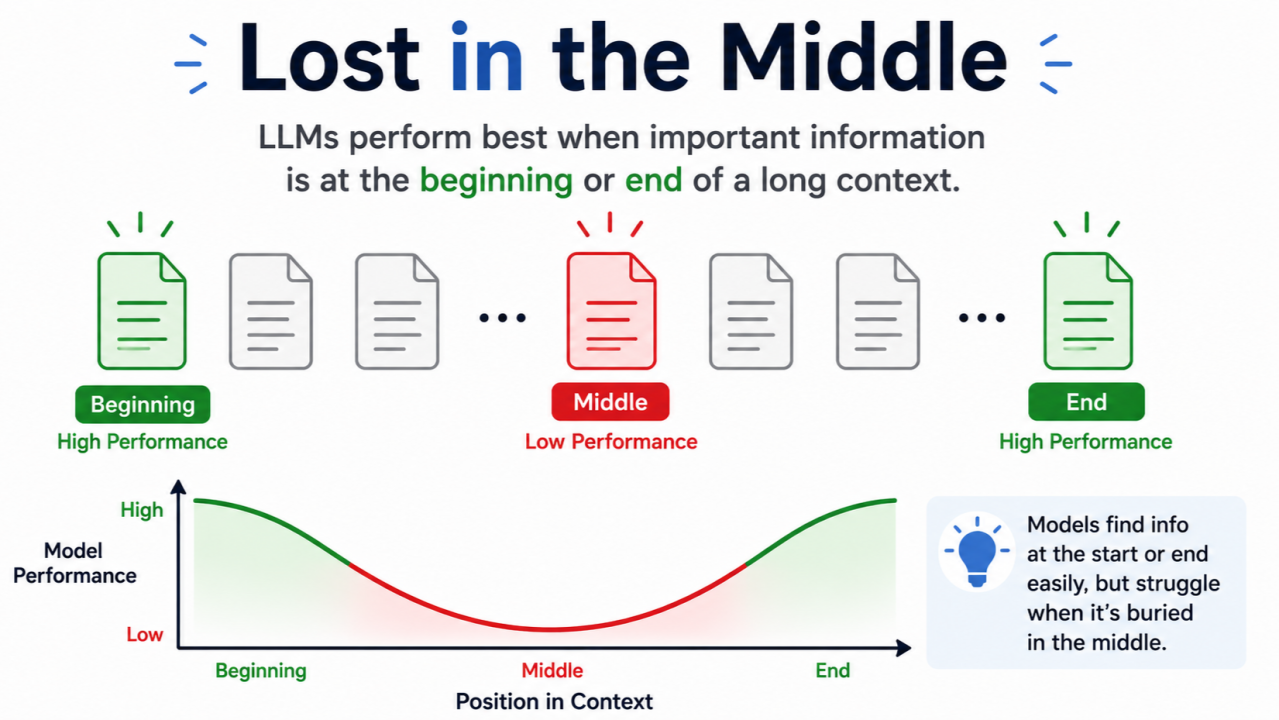


- 이 문제를 줄이기 위해 페이지 단위가 아닌 더 작은 조각으로 문서를 나누는데, 이를 `청킹 (Chunking)`이라 한다.

- LangChain은 Chunking을 위한 다양한 Text Splitter를 제공한다. ([참고 자료](https://reference.langchain.com/python/langchain-text-splitters))
- 이 예시에서는 `RecursiveCharacterTextSplitter`를 사용한다.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
## 최대 250자 단위로 분할하고, 인접 청크끼리 최대 50자까지 겹치게 하여 문맥 단절을 완화
chunk_size    = 250
chunk_overlap = 50

splitter = RecursiveCharacterTextSplitter(
    chunk_size = chunk_size, chunk_overlap = chunk_overlap
)

chunks = splitter.split_documents(documents = document)

print(f'생성된 청크 수 : {len(chunks)}')
print(f'청크 사이즈 : {chunk_size}')
print(f'청크 overlap : {chunk_overlap}')
print('-------\n')

## 앞 3개 청크만 확인
for idx, chunk in enumerate(chunks):

    if idx == 3:
        break

    print(f'[chunk {idx}] \n{chunk.page_content}')
    print('\n--------\n')


⚠️ **Chunk Size나 Overlap을 잘못 설정하면 문맥이 끊긴 Chunk가 생성되므로, 문서 특성에 맞게 신중히 조절해야 한다.**

In [ ]:
## 청크 단위로 벡터 스토어 재생성
vector_store = InMemoryVectorStore.from_documents(
    documents = chunks,
    embedding = embedder
)

## 벡터 스토어에 저장된 청크 수 확인
len(vector_store.store)

In [ ]:
## 청크 기반 벡터 스토어에서 동일한 질문으로 재검색
## - k : 검색할 청크 수 (기본값 4). 청크가 작아 전달되는 문맥도 줄어들므로, 답에 필요한 정보가 빠지면 k를 늘려본다.
retriever         = vector_store.as_retriever(search_kwargs = {'k': 4})
retrieval_results = retriever.invoke(query)

for idx, result in enumerate(retrieval_results):
    print(f"Result {idx + 1}:")
    print(f"Content: {result.page_content}")  ## 청크가 짧으므로 전체 내용 출력
    print(f"Metadata: {result.metadata}")
    print("\n---\n")


In [ ]:
## 청크 기반 retriever로 RetrievalQA 체인 재생성
qa_chain = RetrievalQA.from_chain_type(
    llm = model,
    chain_type = "stuff",
    retriever = retriever
)

result = qa_chain.invoke(query)

print(f'query : {query}')
print(f'answer : {result["result"]}')